In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt

# 序列长度

Running with truncate_ref_len = 100000...
Running with truncate_ref_len = 300000...
Running with truncate_ref_len = 500000...
Running with truncate_ref_len = 700000...
Running with truncate_ref_len = 900000...
   read_time  tree_time  overlap_time  truth_time  query_time  \
0          0         10             0          13          21   
1          0         36             0          39          64   
2          0         65             0          65         103   
3          0         95             0          91         150   
4          0        126             0         117         191   

   truncate_ref_len  
0            100000  
1            300000  
2            500000  
3            700000  
4            900000  


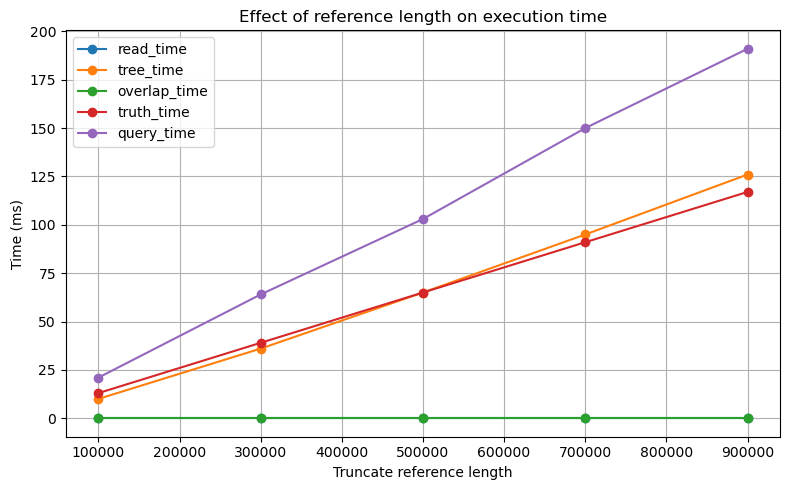

In [8]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围
truncate_values = range(100000, 1000000, 200000)

results = []

for tlen in truncate_values:
    print(f"Running with truncate_ref_len = {tlen}...")
    cmd = [
        EXECUTABLE,
        "--num_anchors", "50",
        "--truncate_ref_len", str(tlen),
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取时间指标
    metrics = {}
    patterns = {
        "read_time":     r"Read FASTQA file time:(\d+)",
        "tree_time":     r"Build Tree time:(\d+)",
        "overlap_time":  r"Calculate overlap time:(\d+)",
        "truth_time":    r"Get ground truth time:(\d+)",
        "query_time":    r"Query time:(\d+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = int(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for truncate_ref_len={tlen}")
            metrics[key] = None

    metrics["truncate_ref_len"] = tlen
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_truncate_time.csv", index=False)

# 画图（每个阶段一个曲线）
plt.figure(figsize=(8,5))
for col in ["read_time", "tree_time", "overlap_time", "truth_time", "query_time"]:
    plt.plot(df["truncate_ref_len"], df[col], marker="o", label=col)

plt.xlabel("Truncate reference length")
plt.ylabel("Time (ms)")
plt.title("Effect of reference length on execution time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./fig/sweep_time_truncate_ref_len.png")
plt.show()


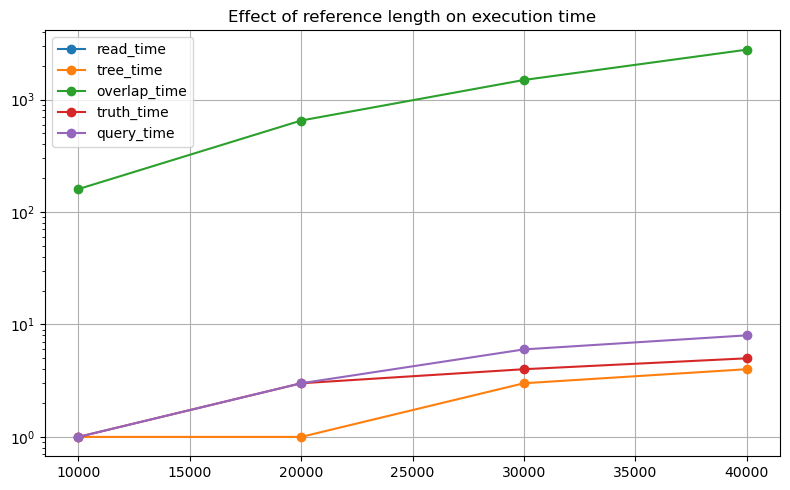

In [6]:
plt.figure(figsize=(8,5))
for col in ["read_time", "tree_time", "overlap_time", "truth_time", "query_time"]:
    plt.plot(df["truncate_ref_len"], df[col], marker="o", label=col)

plt.yscale("log")
plt.title("Effect of reference length on execution time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./fig/sweep_time_truncate_ref_len.png")
plt.show()

# anchor 数量

## anchor 总数

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(2, 100, 5)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o")
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

Running with num_anchors = 2...
Running with num_anchors = 7...
Running with num_anchors = 12...
Running with num_anchors = 17...
Running with num_anchors = 22...
Running with num_anchors = 27...


KeyboardInterrupt: 

Running with num_anchors = 0...


Error running ['../anchor_mapping', '--num_anchors', '0', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--maxDist', '3']: 

stack trace:
  0          [0x406ff2]  ../anchor_mapping()
  1    [0x7f3c5c5ce090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2          [0x431950]  ../anchor_mapping()
  3    [0x7f3c5c5af083]  __libc_start_main + 0xf3
  4          [0x4052de]  ../anchor_mapping()


Running with num_anchors = 100...
Running with num_anchors = 200...
Running with num_anchors = 300...
Running with num_anchors = 400...
Running with num_anchors = 500...
Running with num_anchors = 600...
Running with num_anchors = 700...
Running with num_anchors = 800...
Running with num_anchors = 900...
   avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  num_anchors
0    0.12    0.08    2.88        0.04       0.026286          100
1    0.21    0.20    2.79        0.07       0.037036          200
2    0.30    0.12    2.70        0.10       0.076000          300
3    0.

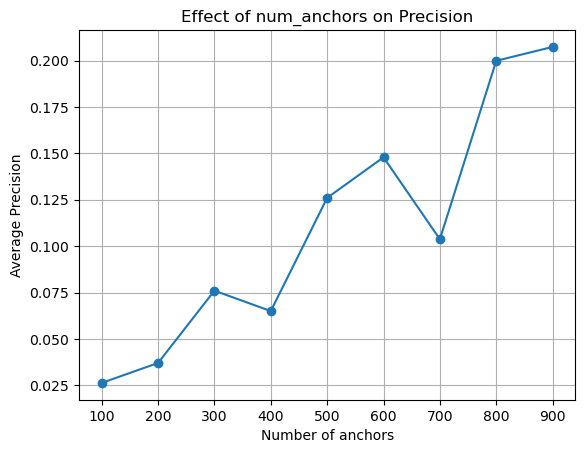

In [ ]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(0, 1000, 100)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout


    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o")
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

In [1]:
import subprocess
import re
import pandas as pd
import os

# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
error_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

results = []

for n in error_values:
    print(f"Running with maxDist = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", str(n),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # --- 提取 split stats ---
    pattern = re.compile(
        r"---- Split stats ----\s*"
        r"Total points:\s*([0-9]+)\s*"
        r"First partition:\s*([0-9]+)\s*"
        r"Second partition:\s*([0-9]+)\s*"
        r"Cross to second:\s*([0-9]+)\s*"
        r"Cross to first:\s*([0-9]+)\s*"
        r"---------------------",
        re.MULTILINE
    )

    results = []
    for m in pattern.finditer(output):
        stats = {
            "total_points": int(m.group(1)),
            "first_partition": int(m.group(2)),
            "second_partition": int(m.group(3)),
            "cross_to_second": int(m.group(4)),
            "cross_to_first": int(m.group(5)),
        }
        results.append(stats)

    # --- 转 DataFrame ---
    df = pd.DataFrame(results)
    df["max_dist"] = n  # 添加当前参数列

    # --- 保存为单独 CSV 文件 ---
    csv_path = f"./csv/split_stats_max_dists_{n}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {csv_path}, {len(df)} rows")


Running with maxDist = 1...
Saved ./csv/split_stats_max_dists_1.csv, 7525 rows
Running with maxDist = 2...
Saved ./csv/split_stats_max_dists_2.csv, 7525 rows
Running with maxDist = 3...
Saved ./csv/split_stats_max_dists_3.csv, 7525 rows
Running with maxDist = 4...
Saved ./csv/split_stats_max_dists_4.csv, 7525 rows
Running with maxDist = 5...
Saved ./csv/split_stats_max_dists_5.csv, 7525 rows
Running with maxDist = 6...
Saved ./csv/split_stats_max_dists_6.csv, 7525 rows
Running with maxDist = 7...
Saved ./csv/split_stats_max_dists_7.csv, 7525 rows
Running with maxDist = 8...
Saved ./csv/split_stats_max_dists_8.csv, 7525 rows
Running with maxDist = 9...
Saved ./csv/split_stats_max_dists_9.csv, 7525 rows
Running with maxDist = 10...
Saved ./csv/split_stats_max_dists_10.csv, 7525 rows
Running with maxDist = 11...
Saved ./csv/split_stats_max_dists_11.csv, 7525 rows
Running with maxDist = 12...
Saved ./csv/split_stats_max_dists_12.csv, 7525 rows
Running with maxDist = 13...
Saved ./csv/split

KeyboardInterrupt: 

In [2]:
import pandas as pd

def compute_mean_overlap_ratio(csv_path: str) -> float:
    """
    从 CSV 文件计算平均 overlap 比例。
    overlap = cross_to_second + cross_to_first
    total = total_points
    返回 overlap/total 的平均值。
    """
    df = pd.read_csv(csv_path)

    # 检查是否包含需要的列
    required_cols = {"cross_to_second", "cross_to_first", "total_points"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"CSV 缺少必要列: {required_cols - set(df.columns)}")

    # 计算 overlap 比例
    df["overlap_ratio"] = (df["cross_to_second"] + df["cross_to_first"]) / df["total_points"]

    # 求平均值
    mean_ratio = df["overlap_ratio"].mean()

    print(f"{csv_path}: mean overlap ratio = {mean_ratio:.4f}")
    return mean_ratio


In [3]:
mean_ratio = compute_mean_overlap_ratio("./csv/split_stats_num_anchors_500.csv")

./csv/split_stats_num_anchors_500.csv: mean overlap ratio = 0.4686


# 允许的 error 范围

Running with maxDist = 1...
Running with maxDist = 2...
Running with maxDist = 3...
Running with maxDist = 4...
Running with maxDist = 5...
Running with maxDist = 6...
Running with maxDist = 7...
Running with maxDist = 8...
Running with maxDist = 9...
Running with maxDist = 10...
Running with maxDist = 11...
Running with maxDist = 12...
Running with maxDist = 13...
Running with maxDist = 14...
Running with maxDist = 15...
Running with maxDist = 16...
Running with maxDist = 17...
Running with maxDist = 18...
Running with maxDist = 19...
Running with maxDist = 20...
     avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  maxDist
0      1.00     0.0     0.0         1.0            1.0        1
1      3.00     0.0     0.0         1.0            1.0        2
2      3.00     0.0     0.0         1.0            1.0        3
3      5.06     0.0     0.0         1.0            1.0        4
4      5.41     0.0     0.0         1.0            1.0        5
5      9.86     0.0     0.0         1.0      

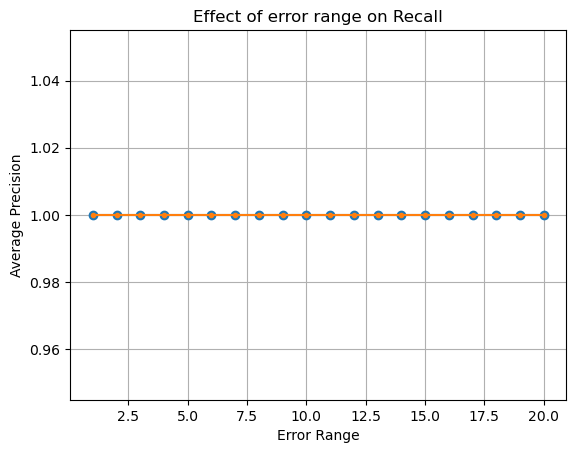

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
error_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

results = []

for n in error_values:
    print(f"Running with maxDist = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", str(n),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for maxDist={n}")
            metrics[key] = None

    metrics["maxDist"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_max_dist.csv", index=False)

# 画图
plt.plot(df["maxDist"], df["avg_precision"], marker="o")
plt.plot(df["maxDist"], df["avg_recall"], marker=".")
plt.xlabel("Error Range")
plt.ylabel("Average Precision")
plt.title("Effect of error range on Recall")
# plt.legend()
plt.grid(True)
plt.savefig("./fig/sweep_precision_max_dist.png")
plt.show()

# anchor距离（滑窗，从近到远稳定 20 个）

In [ ]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围：start_idx, end_idx
idx_ranges = [(i, i+10) for i in range(0, 100, 10)]


results = []

for start_idx, end_idx in idx_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 确保输出目录存在
os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

# 保存结果
df.to_csv("./csv/sweep_results_idx.csv", index=False)

# 画图
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("idx range")
plt.ylabel("Average Precision")
plt.title("Effect of idx range on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_idx.png")
plt.show()

Running with start_idx=0, end_idx=10 ...


Error running ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--use_all', 'false', '--start_idx', '0', '--end_idx', '10']: 

stack trace:
  0          [0x406ff2]  ../anchor_mapping()
  1    [0x7fb299ec0090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2    [0x7fb29a29a5c0]  std::_Hash_bytes(void const*, unsigned long, unsigned long) + 0x30
  3          [0x422afc]  ../anchor_mapping()
  4          [0x42375b]  ../anchor_mapping()
  5          [0x4319a4]  ../anchor_mapping()
  6    [0x7fb299ea1083]  __libc_start_main + 0xf3
  7          [0x4052de]  ../anchor_mapping()


Running with start_idx=10, end_idx=20 ...
Error running ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--use_all', 'false', '--start_idx', '10', '--end_idx', '20']: 

stack trace:
  0          [0x406ff2]  ../anchor_mapping()
  1    [0x7fc4b3554090]  /lib/x86_64-linux-gnu

KeyError: 'start_idx'

# anchor 从近到远的 elbow（选前 n 个）

Running with start_idx=0.000000, end_idx=1.000000 ...


Running with start_idx=0.000000, end_idx=2.000000 ...
Running with start_idx=0.000000, end_idx=3.000000 ...
Running with start_idx=0.000000, end_idx=4.000000 ...
Running with start_idx=0.000000, end_idx=5.000000 ...
Running with start_idx=0.000000, end_idx=6.000000 ...
Running with start_idx=0.000000, end_idx=7.000000 ...
Running with start_idx=0.000000, end_idx=8.000000 ...
Running with start_idx=0.000000, end_idx=9.000000 ...
Running with start_idx=0.000000, end_idx=10.000000 ...
Running with start_idx=0.000000, end_idx=11.000000 ...
Running with start_idx=0.000000, end_idx=12.000000 ...
Running with start_idx=0.000000, end_idx=13.000000 ...
Running with start_idx=0.000000, end_idx=14.000000 ...
Running with start_idx=0.000000, end_idx=15.000000 ...
Running with start_idx=0.000000, end_idx=16.000000 ...
Running with start_idx=0.000000, end_idx=17.000000 ...
Running with start_idx=0.000000, end_idx=18.000000 ...
Running with start_idx=0.000000, end_idx=19.000000 ...
Running with start

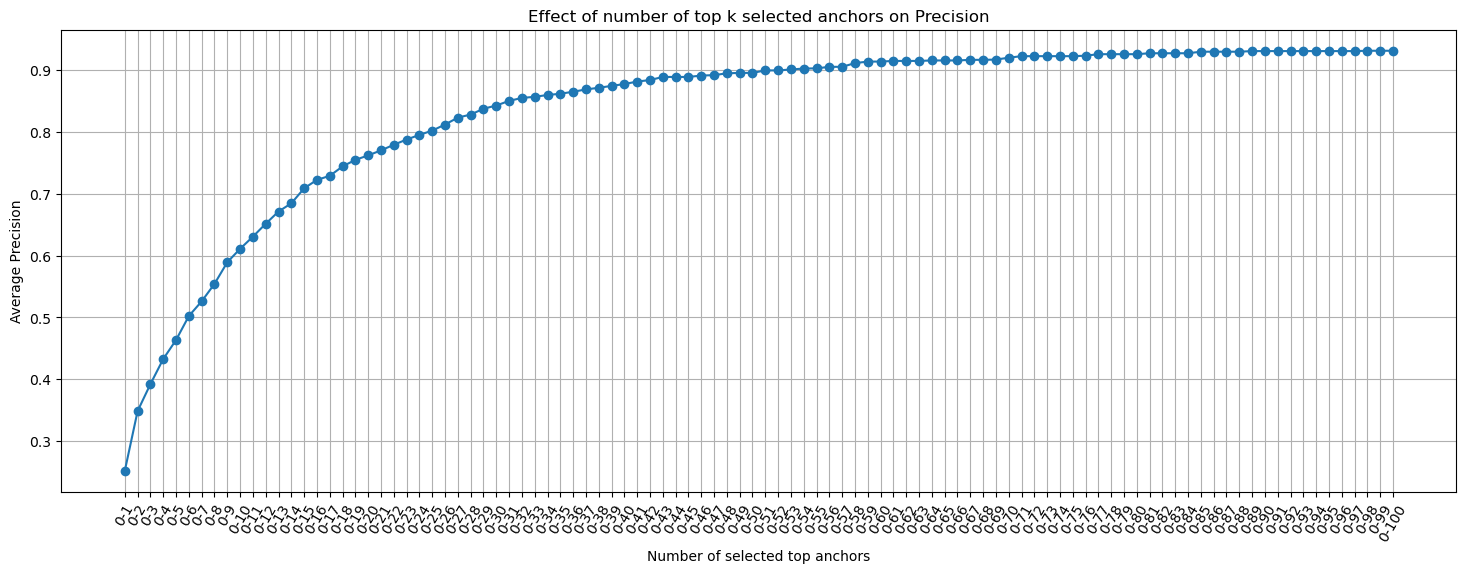

In [ ]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={f"{start_idx:.6f}"}, end_idx={f"{end_idx:.6f}"} ...")
    
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(f"{start_idx:.6f}"),
        "--end_idx", str(f"{end_idx:.6f}"),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
        "end_idx": r"Start and end indexes: 0, \s*([0-9.eE+-]+)"
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.figure(figsize=(18, 6))
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors", )
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors.png")
plt.show()

In [ ]:
df_normal = df.copy()

Running with start_idx=0.0, end_idx=1 ...
Running with start_idx=0.0, end_idx=2 ...
Running with start_idx=0.0, end_idx=3 ...


Running with start_idx=0.0, end_idx=4 ...
Running with start_idx=0.0, end_idx=5 ...
Running with start_idx=0.0, end_idx=6 ...
Running with start_idx=0.0, end_idx=7 ...
Running with start_idx=0.0, end_idx=8 ...
Running with start_idx=0.0, end_idx=9 ...
Running with start_idx=0.0, end_idx=10 ...
Running with start_idx=0.0, end_idx=11 ...
Running with start_idx=0.0, end_idx=12 ...
Running with start_idx=0.0, end_idx=13 ...
Running with start_idx=0.0, end_idx=14 ...
Running with start_idx=0.0, end_idx=15 ...
Running with start_idx=0.0, end_idx=16 ...
Running with start_idx=0.0, end_idx=17 ...
Running with start_idx=0.0, end_idx=18 ...
Running with start_idx=0.0, end_idx=19 ...
Running with start_idx=0.0, end_idx=20 ...
Running with start_idx=0.0, end_idx=21 ...
Running with start_idx=0.0, end_idx=22 ...
Running with start_idx=0.0, end_idx=23 ...
Running with start_idx=0.0, end_idx=24 ...
Running with start_idx=0.0, end_idx=25 ...
Running with start_idx=0.0, end_idx=26 ...
Running with star

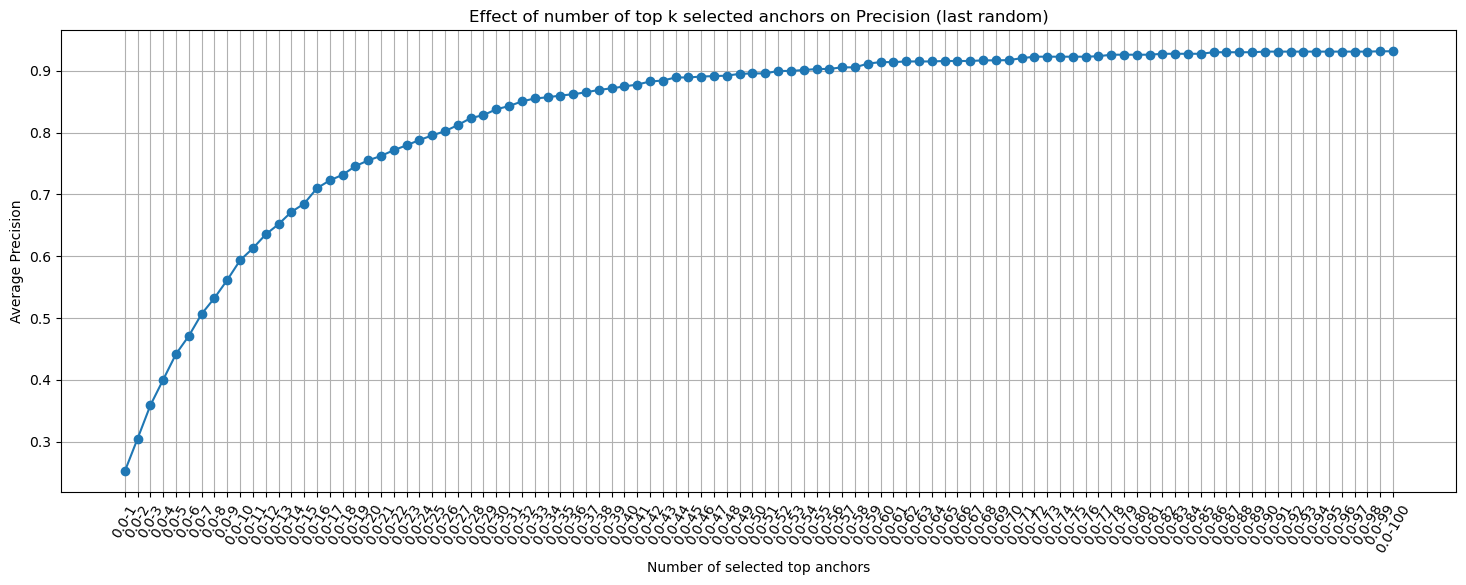

In [ ]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0.0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
        "--last_random", "true"
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors_last_random.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

In [ ]:
df_random = df.copy()

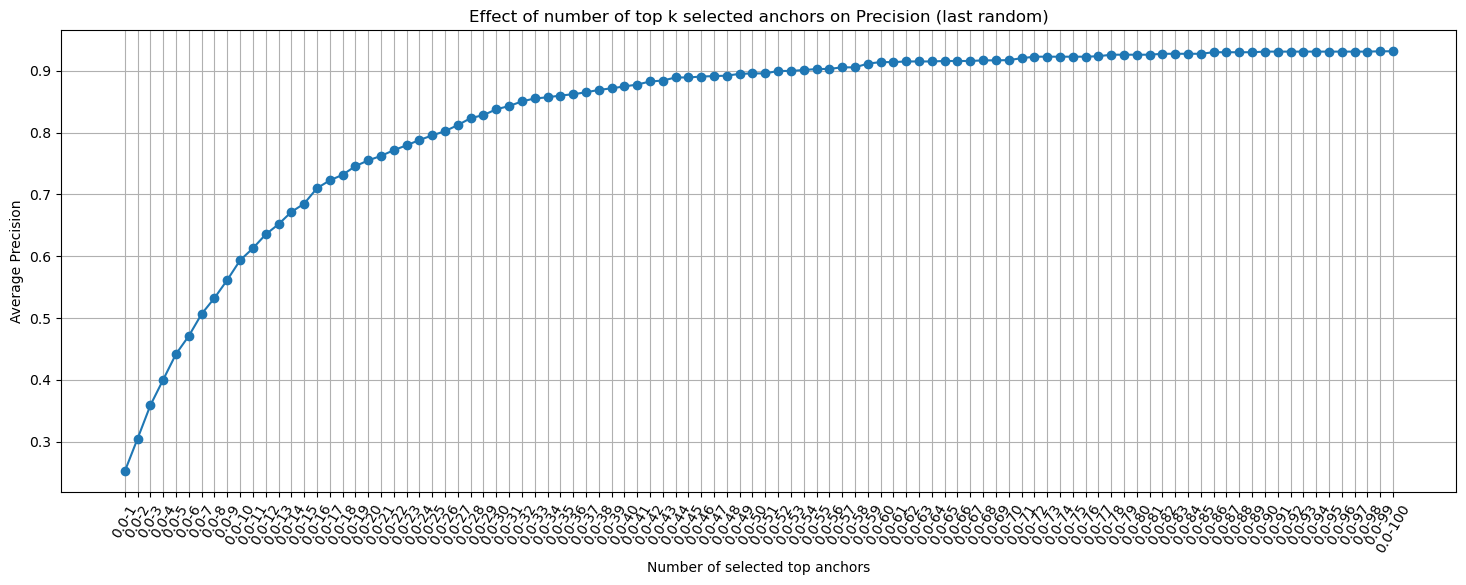

In [ ]:
df = df_random
# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

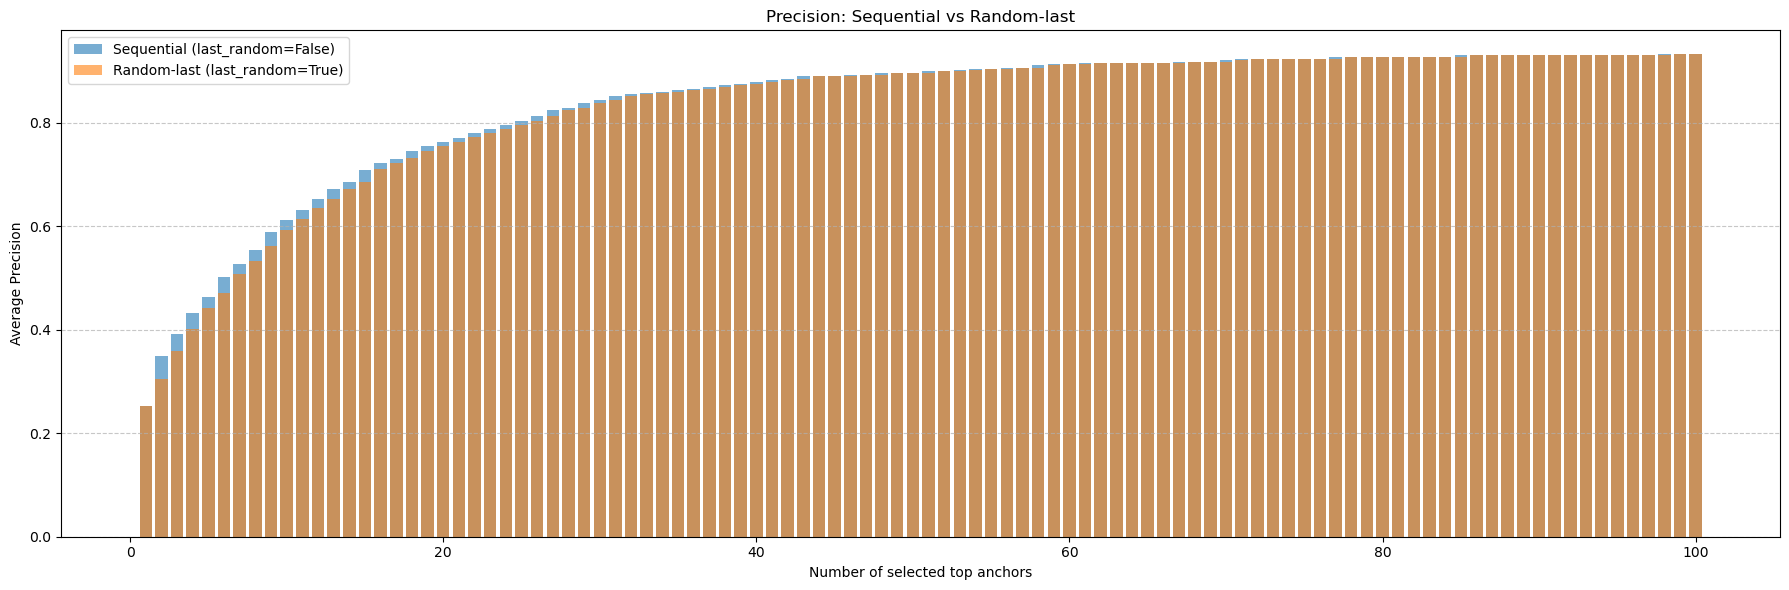

In [ ]:
x = df_normal["selected_anchors"].values
y_normal = df_normal["avg_precision"].values
y_random = df_random["avg_precision"].values

plt.figure(figsize=(18,6))
plt.bar(x, y_normal, alpha=0.6, label="Sequential (last_random=False)")
plt.bar(x, y_random, alpha=0.6, label="Random-last (last_random=True)")

plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.title("Precision: Sequential vs Random-last")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_overlap.png")
plt.show()

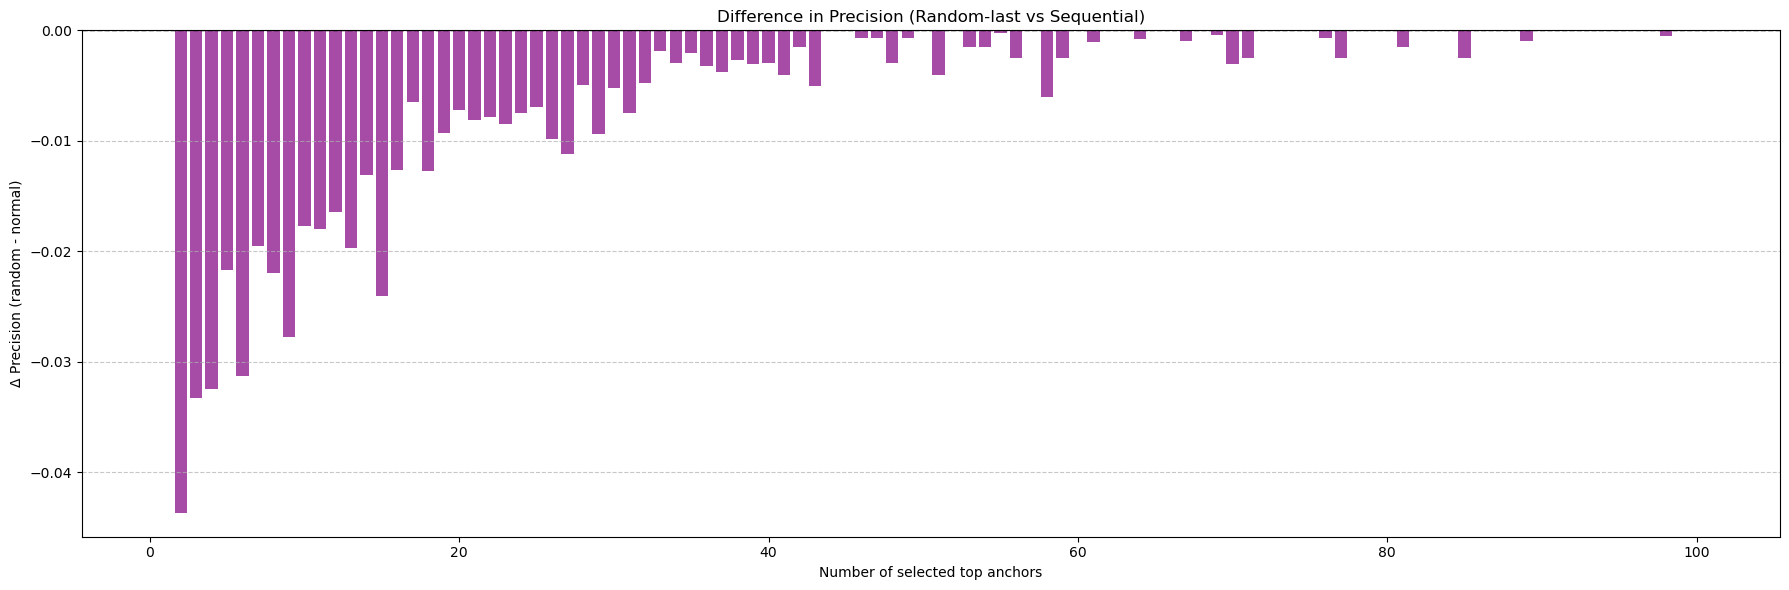

In [ ]:
diff = y_random - y_normal

plt.figure(figsize=(18,6))
plt.bar(x, diff, color="purple", alpha=0.7)

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Δ Precision (random - normal)")
plt.title("Difference in Precision (Random-last vs Sequential)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_difference.png")
plt.show()